['strata/lris2rec/za30/50pGL_50pFA/glao', 'strata/lris2rec/za30/50pGL_50pFA/idealfit', 'strata/lris2rec/za30/50pGL_50pFA/tomo']
['strata/lris2cir/za30/50pGL_50pFA/glao', 'strata/lris2cir/za30/50pGL_50pFA/idealfit', 'strata/lris2cir/za30/50pGL_50pFA/tomo']
['strata/lris2ifu/za30/50pGL_50pFA/glao', 'strata/lris2ifu/za30/50pGL_50pFA/idealfit', 'strata/lris2ifu/za30/50pGL_50pFA/tomo']
['strata/mosfire/za30/50pGL_50pFA/glao', 'strata/mosfire/za30/50pGL_50pFA/idealfit', 'strata/mosfire/za30/50pGL_50pFA/tomo']
['strata/zimager/za30/50pGL_50pFA/glao', 'strata/zimager/za30/50pGL_50pFA/idealfit', 'strata/zimager/za30/50pGL_50pFA/tomo']
['strata/kola/za30/50pGL_50pFA/idealfit', 'strata/kola/za30/50pGL_50pFA/tomo']
['strata/kola/za30/50pGL_50pFA/idealfit'
 'strata/kola/za30/50pGL_50pFA/tomo']


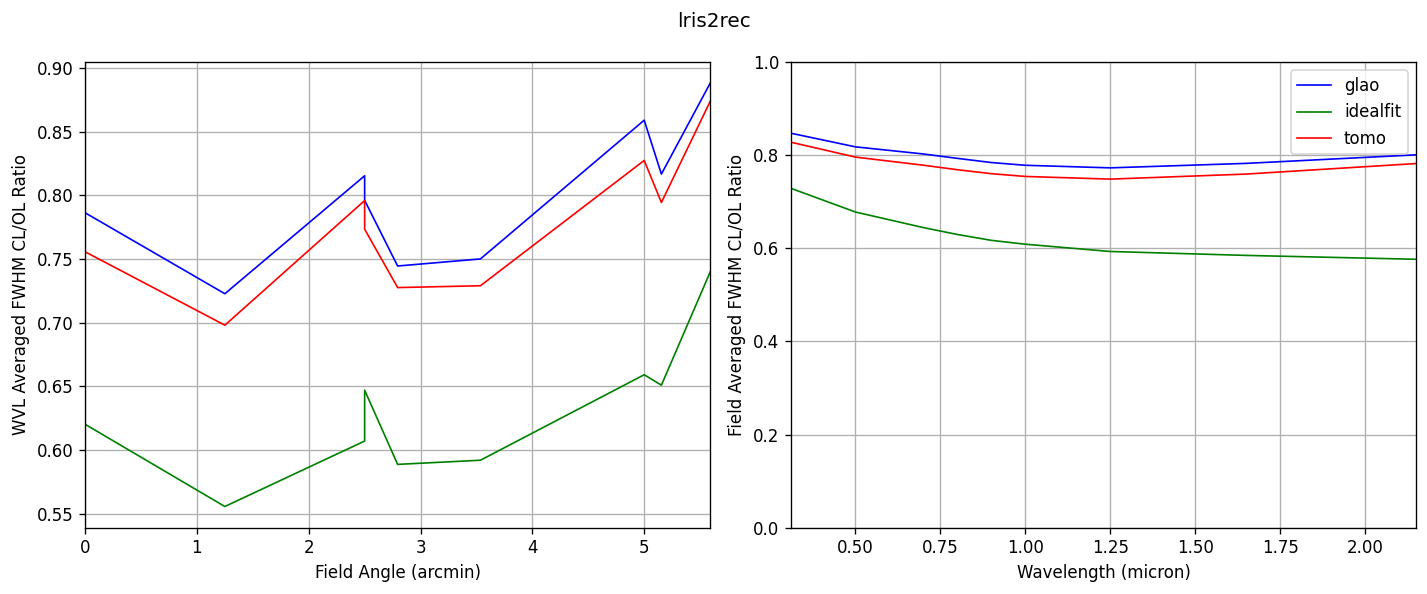

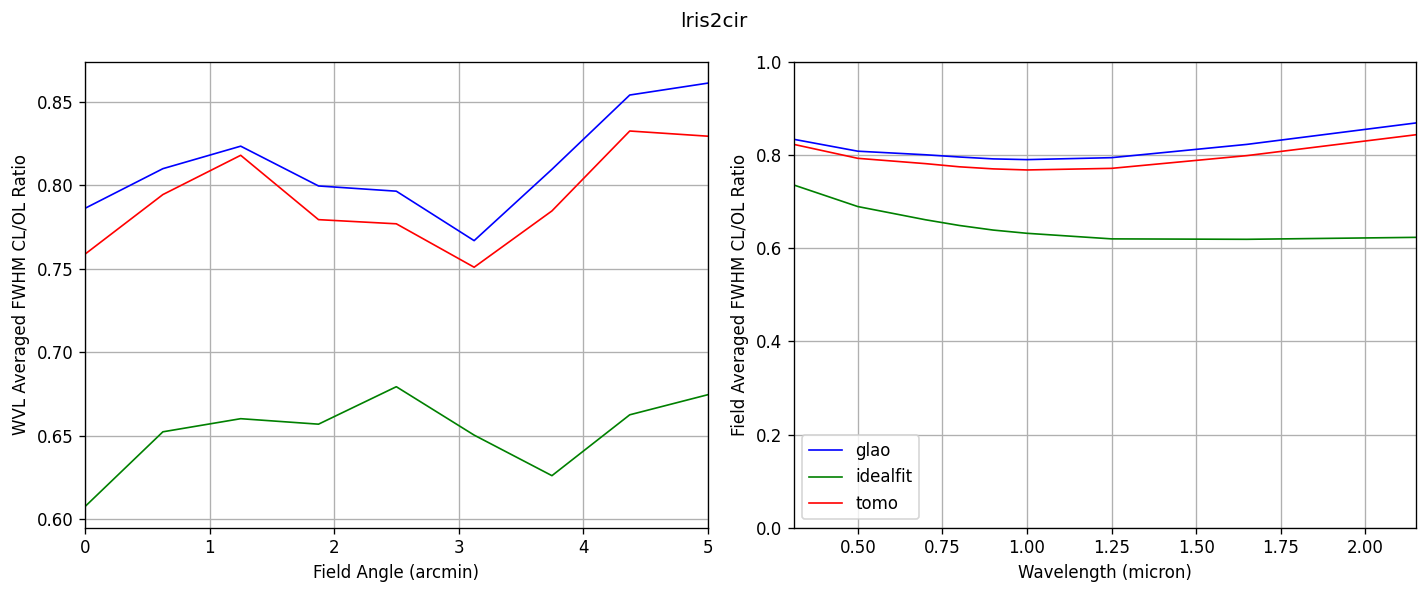

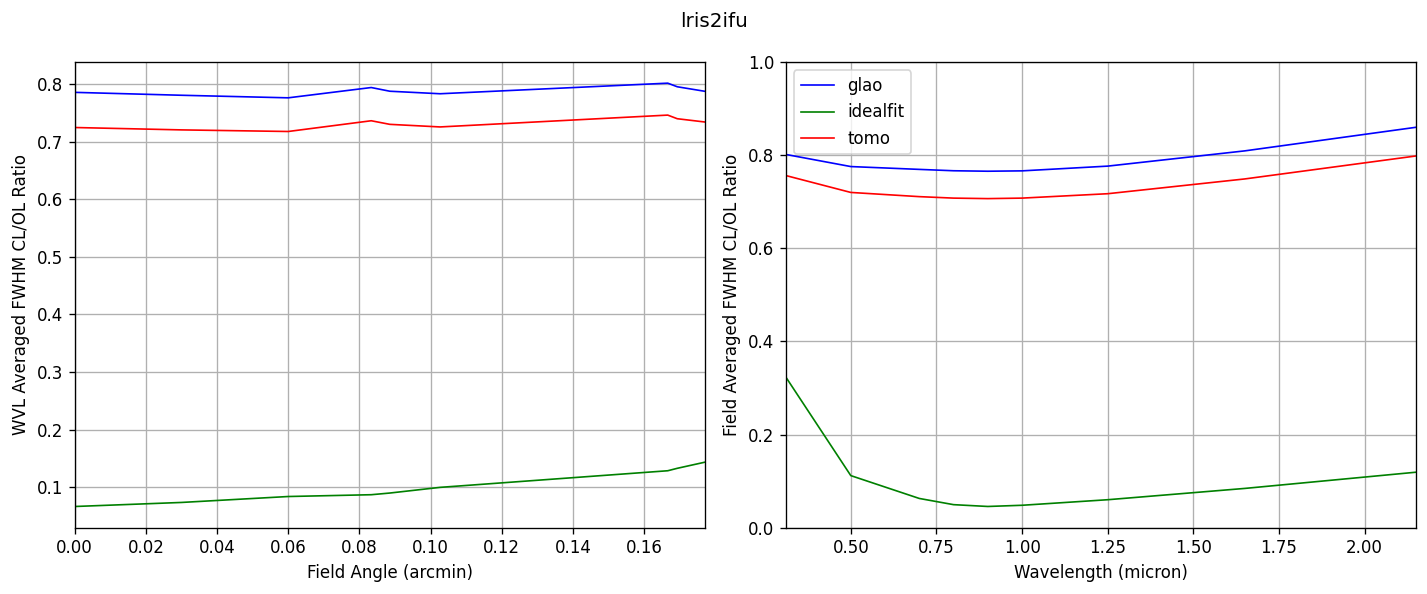

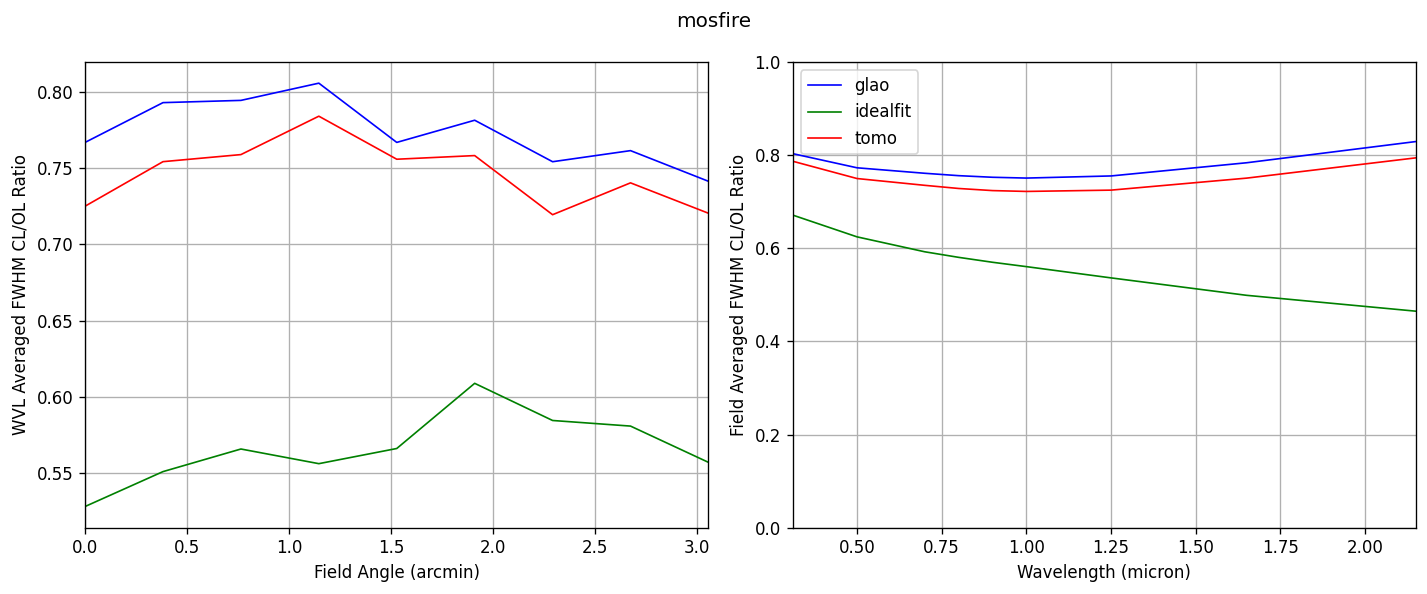

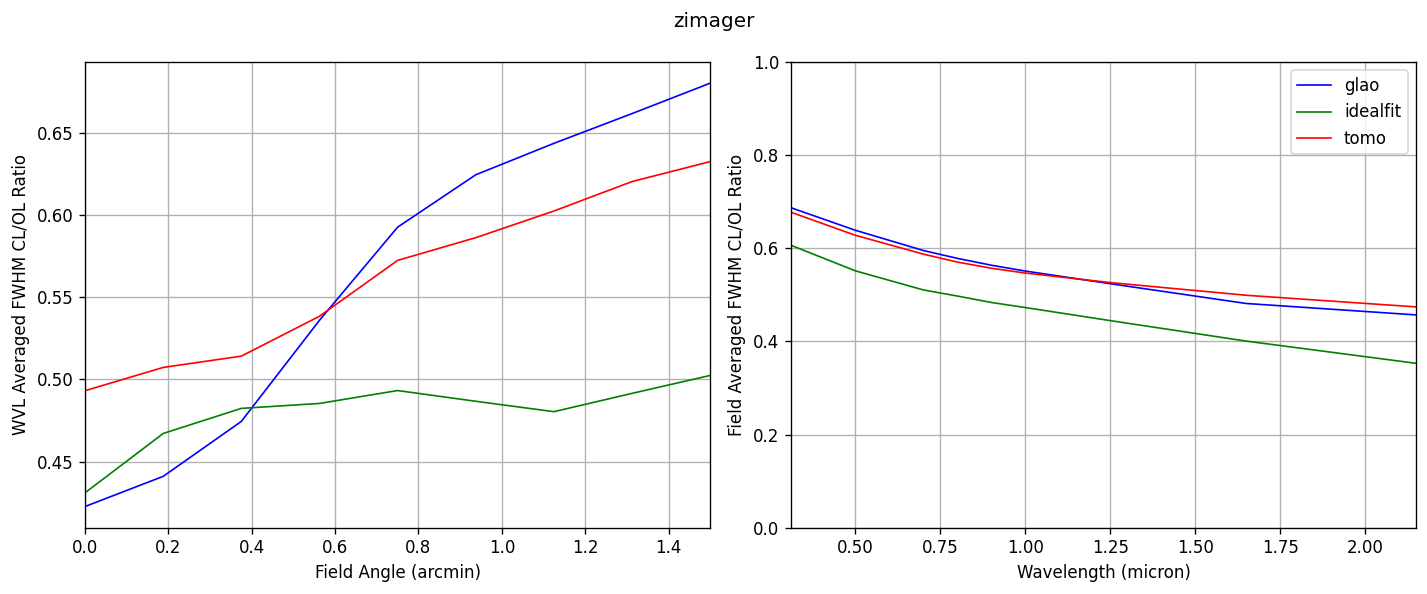

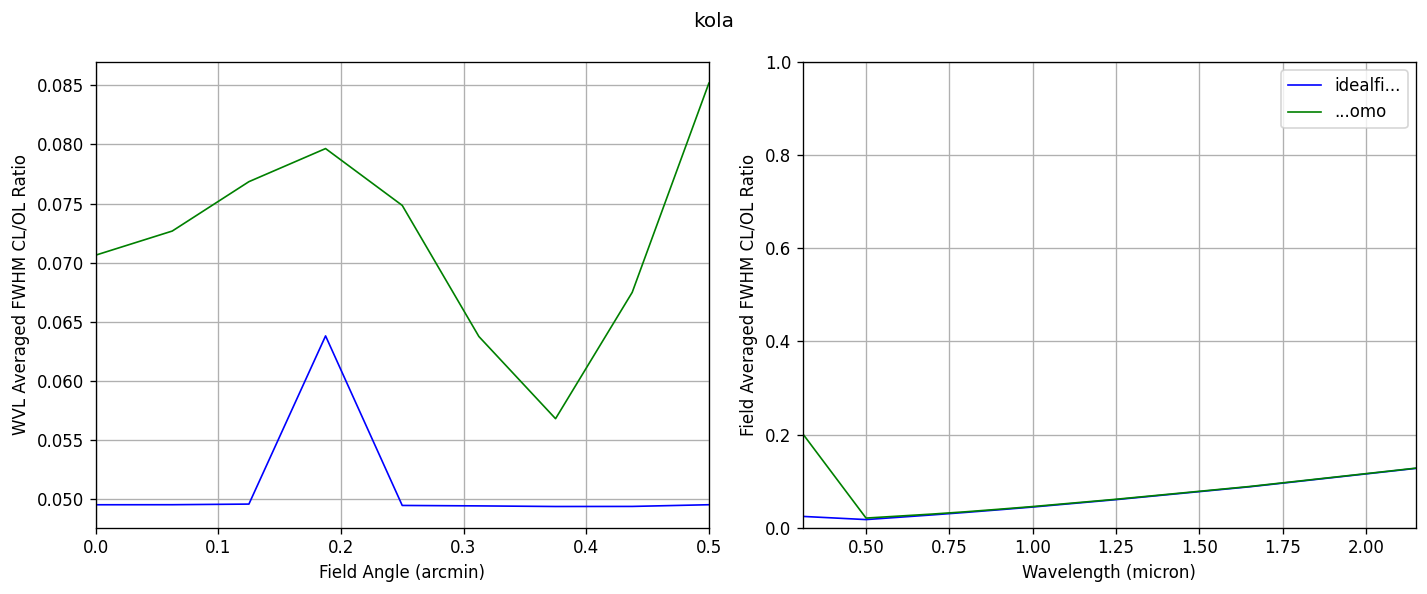

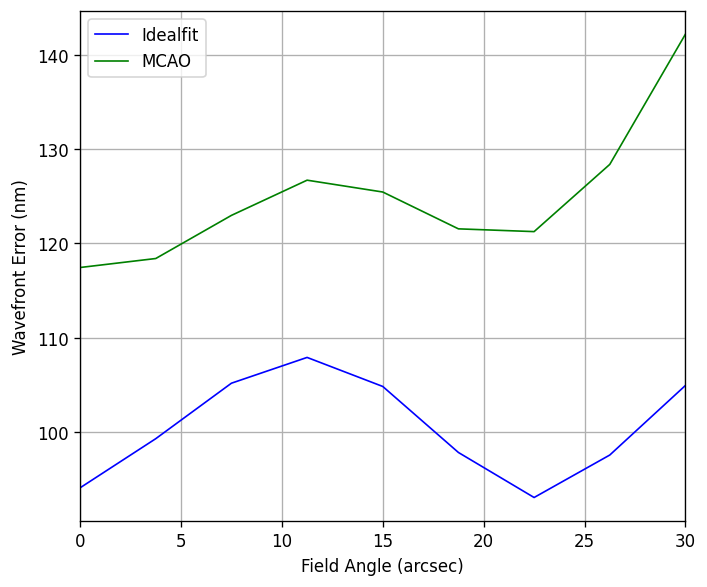

In [1]:
from pathlib import Path
import sys
maos_src=str(Path.home())+"/work/maos/src/scripts" #Adjust based on maos source location
sys.path.append(maos_src) 
import glob
from plot_cfg import *
from maos_psfsize import proc_psfs, strip_common
from maos_result import maos_cumu, maos_res, maos_res_each, maos_res_hi, maos_res_tot
from readbin import readbin as read
try:
    from natsort import natsorted
except:
    natsorted=sorted
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = True
#plot FWHM
for sys in 'lris2rec','lris2cir', 'lris2ifu','mosfire','zimager','kola':
    fds=natsorted(glob.glob(f"strata/{sys}/za30/50pGL_50pFA/*"))
    print(fds)
    tits=strip_common(fds)
    ress=[]
    plt.figure(figsize=(12,5))
    it=0 #0: FWHM. see proc_psf in utils.py
    iwvls=[0,3,5]
    
    for ifd,fd in enumerate(fds):
        res=proc_psfs(fd, seeds=[1])
        ress.append(res)
        wvls=res['wvls']
        if res is None:
            raise(Exception(f'Empty result:{fd}'))
            break
        ratio=res['cl'][:,:,it]/res['ol'][None,:,it] #reduction ratio CL/OL
        plt.subplot(1,2,1)
        plt.plot(res['fr']/60, np.mean(ratio, axis=1))
        plt.xlabel('Field Angle (arcmin)')
        plt.ylabel(f'WVL Averaged FWHM CL/OL Ratio')
        plt.subplot(1,2,2)
        plt.plot(wvls, np.mean(ratio, axis=0))
        plt.xlabel('Wavelength (micron)')
        plt.ylabel(f'Field Averaged FWHM CL/OL Ratio')
        plt.ylim(0,1)
        plt.suptitle(sys)
    plt.legend(tits)
    plt.tight_layout()
#Plot WFE
for sys in 'kola',:
    if sys=='kola':
        tr=np.arange(9)/8*30
    res, fds=maos_res_each(f"strata/{sys}/za30/50pGL_50pFA/*")
    print(fds)
    tits=strip_common(fds.tolist())
    plt.figure(figsize=(6,5))
    plt.plot(tr, np.sqrt(res[:,:,0]).T) #piston removed
    plt.legend(('Idealfit','MCAO'))
    plt.xlabel('Field Angle (arcsec)')
    plt.ylabel('Wavefront Error (nm)')

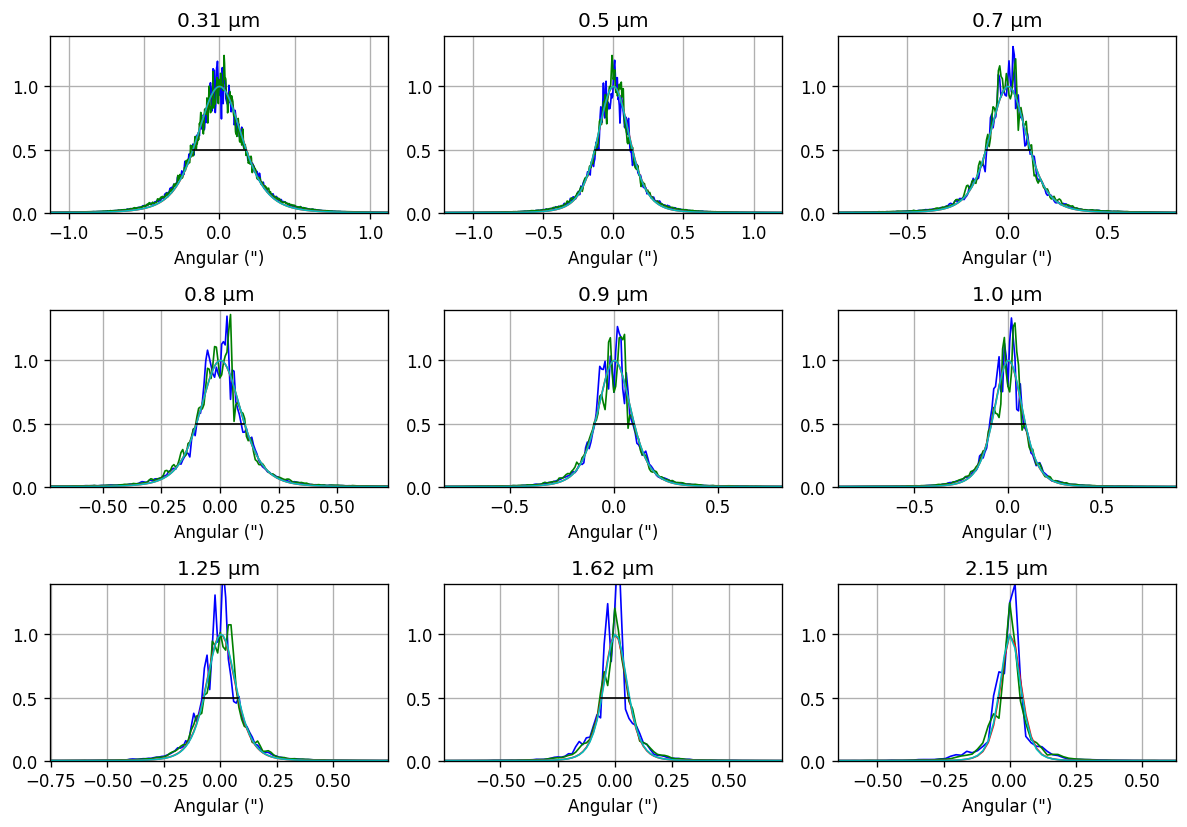

In [2]:
#Verify FWHM calculation using Mofatt fitting
from maos_psfsize import *
from aotools import *
fd='strata/zimager/za30/50pGL_50pFA/idealfit/'
wvl=np.array([0.31, 0.5,  0.7 , 0.8,  0.9,  1. ,  1.25 ,1.62 ,2.15])
seed=1
if True:
    fn=f"{fd}/evlpsfcl_{seed}_x0_y0.fits"
    #fn=f"{fd}/evlpsfol_{seed}.fits"
    datas=read(fn)
    dps=parse_header_float(datas, 'DP')
    ic=1
    plt.figure(figsize=(10,7))
    for iwvl in range(9):
        plt.subplot(3,3,ic)
        ic+=1
        img=datas[iwvl]
        #xlim(-1,1)
        fit=fit_moffat_roi(img)
        #print(fit)
        ny, nx = img.shape
        y, x = np.mgrid[:ny, :nx]
        model_img = fit(x, y)
        #print(fit.gamma.value, fit.alpha.value)
        #fwhm=fit.fwhm.value
        fwhm=2*fit.gamma.value*np.sqrt(2**(1/fit.alpha.value)-1)*dps[iwvl]
        norm=1/np.max(np.max(model_img))
        plot_cross(img*norm, dx=dps[iwvl])#,c='r',ls='-')
        plot_cross(img.T*norm, dx=dps[iwvl])#,c='b',ls='-')
        plot_cross(model_img*norm, dx=dps[iwvl])#,c='c',ls='-')
        plot_cross(model_img.T*norm, dx=dps[iwvl])#,c='m',ls='-')
        plot([-fwhm/2,fwhm/2],[0.5,0.5],'k')
        #xlim(np.array([-1,1])*fwhm*2)
        ylim(0,1.4)
        plt.gca().autoscale(enable=True, axis='x', tight=True)
        title(f'{wvl[iwvl]} µm')
        xlabel('Angular (")')
    plt.tight_layout()